# LongSANA Tiny Diffusion Prototype (Local Dataset Edition)

This notebook implements a "tiny" version of the LongSANA training pipeline, now upgraded to train on **all available samples** in the local `cleansed` directory.

### Goals:
1. **Multi-Sample Training:** Uses a proper PyTorch `DataLoader` to iterate over all worlds.
2. **Real Components:** Uses `t5-small` for text and real `Conv3D` layers for the Autoencoder and DiT.
3. **Blackwell Compatibility:** Optimized for `sm_120` GPUs (RTX 50-series) with aggressive spatial cropping.

In [30]:
import os
import numpy as np
import blosc2
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import T5EncoderModel, T5Tokenizer
from tqdm.auto import tqdm

# Set paths relative to your local setup
PROJECT_ROOT = Path("../../")
PROCESSED_DIR = PROJECT_ROOT / "tmp" / "processed_worlds"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project Root: {PROJECT_ROOT.absolute()}")
print(f"Using Device: {DEVICE}")

Project Root: C:\PROJECTS\MC\src\notebooks\..\..
Using Device: cuda


## 1. Data Loading (Multi-Sample Dataset)
We crawl the `cleansed` directory to find all voxel volumes and their corresponding captions.

In [31]:
class MinecraftDataset(Dataset):
    def __init__(self, processed_dir, target_size=(64, 64, 16)):
        self.cleansed_dir = Path(processed_dir) / "cleansed"
        self.target_size = target_size
        self.samples = self._discover_samples()
        
        # Initialize a consistent random palette for visualization
        self.palette = np.random.rand(512, 3) # Max 512 block IDs
        self.palette[0] = [0.8, 0.9, 1.0]      # Air color
        
    def _discover_samples(self):
        samples = []
        if not self.cleansed_dir.exists(): 
            print(f"WARNING: {self.cleansed_dir} not found")
            return []
            
        for world_dir in self.cleansed_dir.iterdir():
            volumes_dir = world_dir / "volumes"
            captions_dir = world_dir / "captions"
            if volumes_dir.exists() and captions_dir.exists():
                frames = sorted(list(volumes_dir.glob("*.b2frame")))
                caps = sorted(list(captions_dir.glob("*.txt")))
                # Match frames to captions (assumes 1-to-1 matching by sort order)
                for f, c in zip(frames, caps):
                    samples.append({"volume": f, "caption": c})
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample_paths = self.samples[idx]
        
        # Load Voxel Grid
        with open(sample_paths["volume"], "rb") as f:
            volume = blosc2.unpack_array2(f.read())
            
        # Load Caption
        with open(sample_paths["caption"], "r") as f: 
            caption = f.read().strip()
            
        # 1. Processing (X, Z, Y) -> (64, 64, 16)
        X, Z, Y = volume.shape
        t_x, t_z, t_y = self.target_size
        
        start_x = max(0, (X - t_x) // 2)
        start_z = max(0, (Z - t_z) // 2)
        cropped = volume[start_x:start_x+t_x, start_z:start_z+t_z, :t_y]
        
        # Ensure consistency if file is smaller than target
        padded = np.zeros((t_x, t_z, t_y), dtype=volume.dtype)
        cur_x, cur_z, cur_y = cropped.shape
        padded[:cur_x, :cur_z, :cur_y] = cropped
        
        # 2. Block-to-RGB Mapping
        # Clip indices to palette size
        padded_clipped = np.clip(padded, 0, len(self.palette)-1)
        rgb_vol = self.palette[padded_clipped].astype(np.float32)
        
        # 3. Formatting (H, W, T, C) -> (C, T, H, W)
        tensor = torch.from_numpy(rgb_vol).permute(3, 2, 0, 1)
        
        return tensor, caption

dataset = MinecraftDataset(PROCESSED_DIR)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, pin_memory=True)
print(f"Dataset Size: {len(dataset)}")

Dataset Size: 110


## 2. Setup Trainable Model Components
Identical to single-sample version, but these will now generalize across the dataset.

In [32]:
class TinyTextEncoder(nn.Module):
    def __init__(self, model_name="t5-small"):
        super().__init__()
        try:
            self.encoder = T5EncoderModel.from_pretrained(model_name).to(DEVICE)
            self.tokenizer = T5Tokenizer.from_pretrained(model_name)
            self.active = True
        except:
            print("Reverting to Random Embeddings for Text")
            self.active = False
            
    def forward(self, text_list):
        if not self.active:
            return torch.randn(len(text_list), 1, 512).to(DEVICE)
        # Batch tokenization
        inputs = self.tokenizer(text_list, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
        outputs = self.encoder(**inputs)
        return outputs.last_hidden_state

class TinyVAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv3d(in_channels, 16, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.ReLU(),
            nn.Conv3d(16, latent_dim, kernel_size=3, stride=(1, 2, 2), padding=1),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(latent_dim, 16, kernel_size=3, stride=(1, 2, 2), padding=1, output_padding=(0, 1, 1)),
            nn.ReLU(),
            nn.ConvTranspose3d(16, in_channels, kernel_size=3, stride=(1, 2, 2), padding=1, output_padding=(0, 1, 1)),
            nn.Sigmoid()
        )
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)

class TinyDiT(nn.Module):
    def __init__(self, latent_dim=4, text_dim=512):
        super().__init__()
        self.conv1 = nn.Conv3d(latent_dim, 32, kernel_size=3, padding=1)
        self.text_mlp = nn.Linear(text_dim, 32)
        self.conv2 = nn.Conv3d(32, latent_dim, kernel_size=3, padding=1)
        
    def forward(self, x, text_emb, t):
        text_cond = text_emb.mean(dim=1)
        text_feat = self.text_mlp(text_cond).view(x.shape[0], 32, 1, 1, 1)
        h = F.relu(self.conv1(x)) + text_feat
        return self.conv2(h)

text_enc = TinyTextEncoder()
vae = TinyVAE().to(DEVICE)
dit = TinyDiT().to(DEVICE)
print("Models initialized.")

Models initialized.


## 3. Training Loop (Multi-Epoch Edition)
We now train across the whole dataset.

Training Started for 10 epochs...


Epoch 9: 100%|██████████| 55/55 [00:06<00:00,  9.06it/s, loss=0.0314]


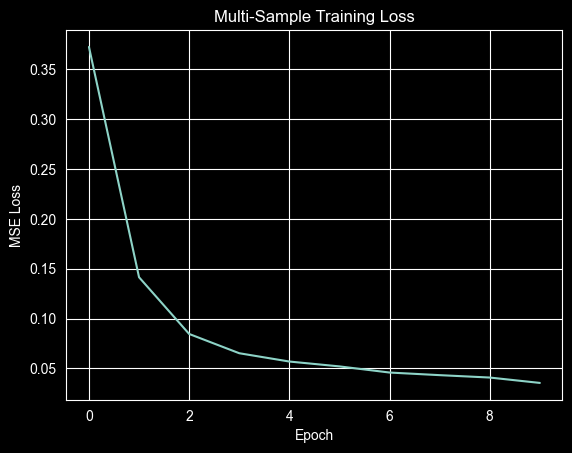

In [33]:
optimizer = torch.optim.AdamW(list(vae.parameters()) + list(dit.parameters()), lr=1e-3)
mse_loss = nn.MSELoss()
epochs = 10

print(f"Training Started for {epochs} epochs...")
history = []

for epoch in range(epochs):
    epoch_loss = 0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch}")
    for batch_voxels, batch_captions in pbar:
        batch_voxels = batch_voxels.to(DEVICE)
        
        # 1. Encode text and hidden latents
        text_emb = text_enc(batch_captions)
        clean_latents = vae.encode(batch_voxels)
        
        # 2. Diffusion step
        noise = torch.randn_like(clean_latents)
        t = torch.randint(0, 1000, (batch_voxels.shape[0],)).to(DEVICE)
        noisy_latents = clean_latents + noise
        
        # 3. Predict and update
        pred_noise = dit(noisy_latents, text_emb, t)
        loss = mse_loss(pred_noise, noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
    history.append(epoch_loss / len(dataloader))

plt.plot(history)
plt.title("Multi-Sample Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

## 4. Model Persistence
Save and load the trained models to iterate on results without retraining.

In [36]:
MODEL_DIR = PROJECT_ROOT / "models" / "tiny_diffusion"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

VAE_PATH = MODEL_DIR / "vae_tiny.pt"
DIT_PATH = MODEL_DIR / "dit_tiny.pt"

def save_models():
    torch.save(vae.state_dict(), VAE_PATH)
    torch.save(dit.state_dict(), DIT_PATH)
    print(f"Models saved to {MODEL_DIR}")

def load_models():
    # Note: Ensure vae and dit are initialized before calling this
    vae.load_state_dict(torch.load(VAE_PATH, map_location=DEVICE))
    dit.load_state_dict(torch.load(DIT_PATH, map_location=DEVICE))
    print(f"Models loaded from {MODEL_DIR}")

save_models() # Uncomment to save after training
load_models() # Uncomment to load previously saved weights

Models saved to ..\..\models\tiny_diffusion
Models loaded from ..\..\models\tiny_diffusion


## 5. Sampling & 3D Visualization
Select a random sample from the dataset to verify reconstruction.

Visualizing Sample: A Minecraft scene.


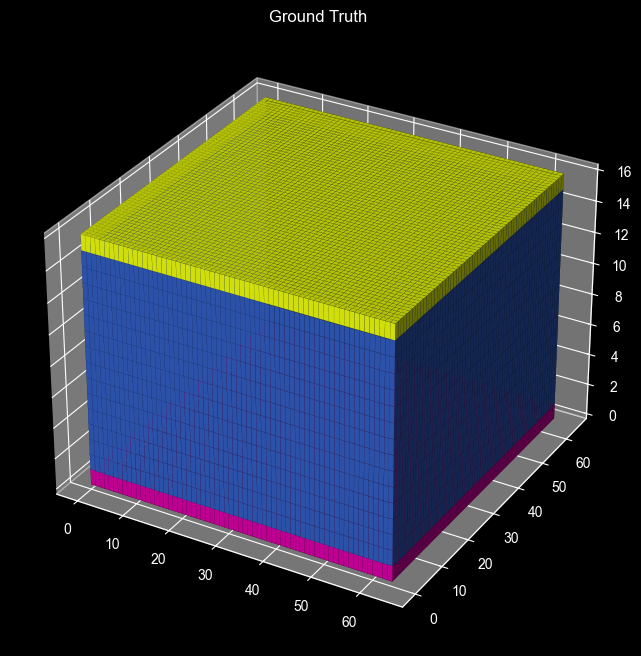

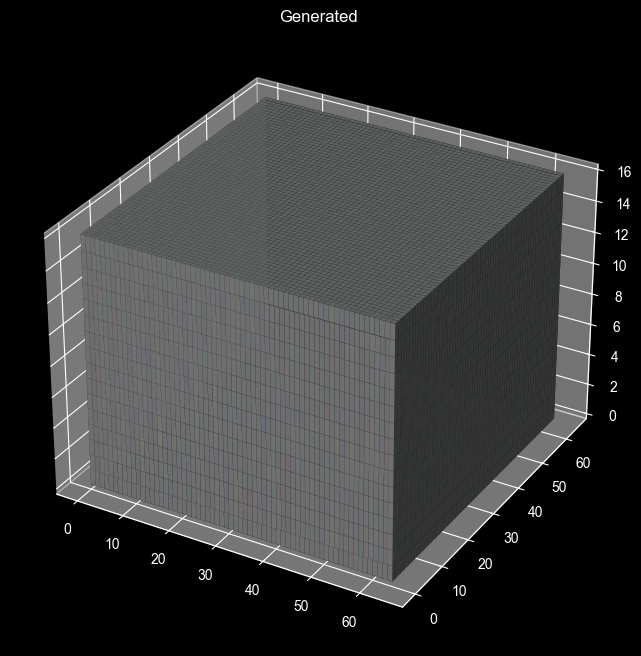

In [37]:
def plot_voxels_3d(rgb_vol, title="3D Voxel Visualization"):
    # Simple heuristic to identify background
    is_air = (rgb_vol[..., 0] > 0.7) & (rgb_vol[..., 1] > 0.8) & (rgb_vol[..., 2] > 0.9)
    voxels = ~is_air
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.voxels(voxels, facecolors=rgb_vol, edgecolor='k', linewidth=0.05)
    ax.set_title(title)
    plt.show()

with torch.no_grad():
    # Get a real sample for comparison
    gt_tensor, gt_caption = dataset[0]
    gt_tensor = gt_tensor.unsqueeze(0).to(DEVICE)
    
    # Denoise from pure noise
    z = torch.randn(1, 4, 16, 16, 16).to(DEVICE)
    emb = text_enc([gt_caption])
    pred_noise = dit(z, emb, torch.zeros(1).to(DEVICE))
    
    # Decode
    gen_tensor = vae.decode(z - pred_noise).squeeze(0).permute(2, 3, 1, 0).cpu().numpy()
    gt_np = gt_tensor.squeeze(0).permute(2, 3, 1, 0).cpu().numpy()

print(f"Visualizing Sample: {gt_caption}")
plot_voxels_3d(gt_np, "Ground Truth")
plot_voxels_3d(gen_tensor, "Generated")